In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
# import warnings
# warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

In [62]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv", header = None)
df.head()

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [63]:
df.columns = [ 'age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region', 'charges' ]
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv", names = None)
df 

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,47,1,45.320,1,0,4,8569.86180
2768,21,1,34.600,0,0,3,2020.17700
2769,19,2,26.030,1,1,1,16450.89470
2770,23,2,18.715,0,0,1,21595.38229


In [64]:
df.replace("?", np.nan, inplace = True)
df.head(5)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [65]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


,age,gender,bmi,no_of_children,smoker,region,charges
count,2768,2772.000000,2772.000000,2772.000000,2765,2772.000000,2772.000000
unique,47,NaN,NaN,NaN,2,NaN,NaN
top,18,NaN,NaN,NaN,0,NaN,NaN
freq,148,NaN,NaN,NaN,2201,NaN,NaN
mean,NaN,1.507215,30.701349,1.101732,NaN,2.559885,13261.369959
std,NaN,0.500038,6.129449,1.214806,NaN,1.130761,12151.768945
min,NaN,1.000000,15.960000,0.000000,NaN,1.000000,1121.873900
25%,NaN,1.000000,26.220000,0.000000,NaN,2.000000,4687.797000
50%,NaN,2.000000,30.447500,1.000000,NaN,3.000000,9333.014350
75%,NaN,2.000000,34.770000,2.000000,NaN,4.000000,16577.779500


In [66]:
avg_age = df["age"].astype("float").mean(axis=0)
print("Average of age:", round(avg_age))

is_smoker = df['smoker'].value_counts().idxmax()


Average of age: 39


In [67]:
df["age"] = (
    df["age"]
      .replace(np.nan, round(avg_age))
      .infer_objects(copy=False)
)

df["smoker"] = (
    df["smoker"]
      .replace(np.nan, is_smoker)
      .infer_objects(copy=False)
)



In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [69]:
df["charges"] = (
    df["charges"].round(2)
    .infer_objects(copy=False)
)

In [70]:
df["charges"]

0       16884.92
1        1725.55
2        4449.46
3       21984.47
4        3866.86
          ...   
2767     8569.86
2768     2020.18
2769    16450.89
2770    21595.38
2771     9850.43
Name: charges, Length: 2772, dtype: float64

In [78]:
df[["bmi", "charges"]].describe()


,bmi,charges
count,2772.000000,2772.000000
mean,30.701349,13261.369957
std,6.129449,12151.768970
min,15.960000,1121.870000
25%,26.220000,4687.800000
50%,30.447500,9333.015000
75%,34.770000,16577.780000
max,53.130000,63770.430000


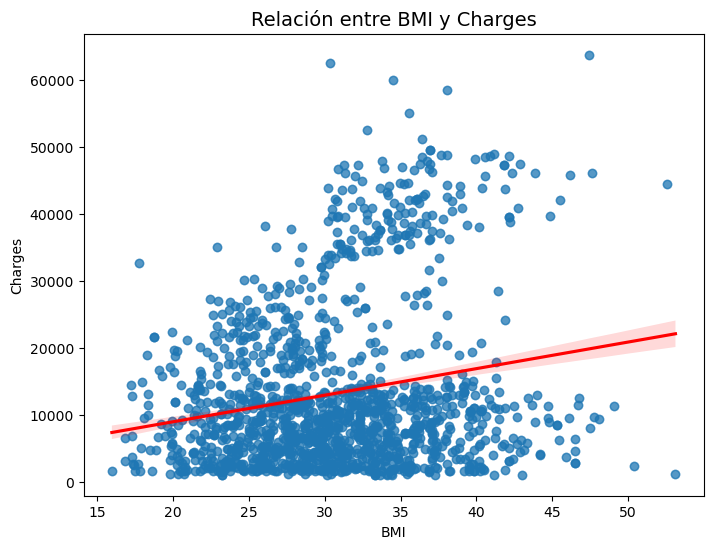

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reiniciar figura (a veces Jupyter se "traba" con gráficos previos)
plt.close('all')

# Crear el gráfico
plt.figure(figsize=(8,6))
sns.regplot(x=df["bmi"], y=df["charges"], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

# Personalización
plt.title("Relación entre BMI y Charges", fontsize=14)
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

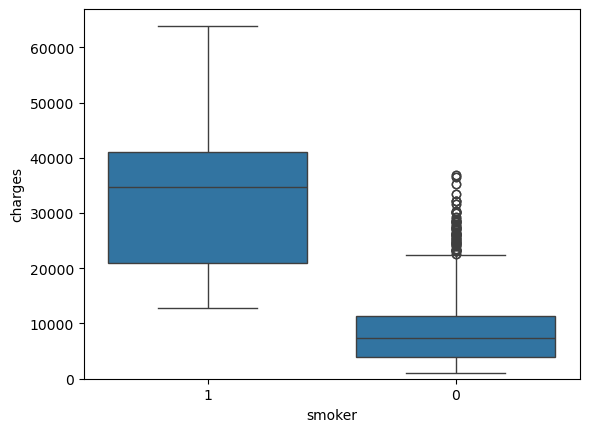

In [85]:
sns.boxplot(x="smoker", y="charges", data=df)

# sns.boxplot(x="engine-location", y="price", data=df)

plt.ylim(0,)

plt.show()

In [86]:
df.corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
gender,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


In [88]:
lm = LinearRegression()
X = df[['smoker']]
Y = df['charges']
lm.fit(X,Y)

LinearRegression()

In [90]:
print(lm.score(X,Y))

0.6221791733924185


In [94]:
lm = LinearRegression()
Z = df[['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region']]
Y = df['charges']
lm.fit(Z,Y)
print(lm.score(Z,Y))

0.7504083820289634


In [96]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [99]:
Z = Z.astype(float)
pipe.fit(Z,Y)


Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [100]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([24010.,  2990.,  5422.,  4720.])

In [101]:
print(r2_score(Y,ypipe))

0.8450466807031618


In [103]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.20, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 555
number of training samples: 2217


In [105]:
from sklearn.linear_model import Ridge

RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.6760807731582406


In [106]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.fit_transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.7835631107608061
